# 03 — Results Visualisation

Figures for the results section of the paper. Plotting functions live in
`src/results_viz.py`; this notebook calls them and saves the output to
`docs/figures/`.

Sections:
1. Training curves (loss + val ACER per epoch, per fold)
2. CV fold stability (per-fold ACER spread)
3. Within-dataset test-set bar charts
4. Cross-dataset generalisation bar charts
5. ROC curves (within-dataset and cross-dataset)


In [7]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
from src.config import CHECKPOINT_DIR, DOCS_DIR
from src import results_viz

FIG_DIR = DOCS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cv_runs = results_viz.load_cv_summaries(CHECKPOINT_DIR)
test_results = results_viz.load_test_results(Path("../outputs/test_eval_results.json"))

print(f"CV runs: {list(cv_runs.keys())}")
print(f"Test sections: {list(test_results.keys())}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CV runs: ['both-cv-5', 'replay-cv-5', '3dmad-cv-5']
Test sections: ['within_dataset', 'cross_dataset_raw', 'cross_dataset_calibrated']


## 1. Training curves

Training loss (top) and validation ACER (bottom) over epochs for each
protocol. Thin lines are individual folds, thick line is the fold-mean.
Early stopping cuts each fold at a different epoch — the ragged right
edges show when each fold converged.


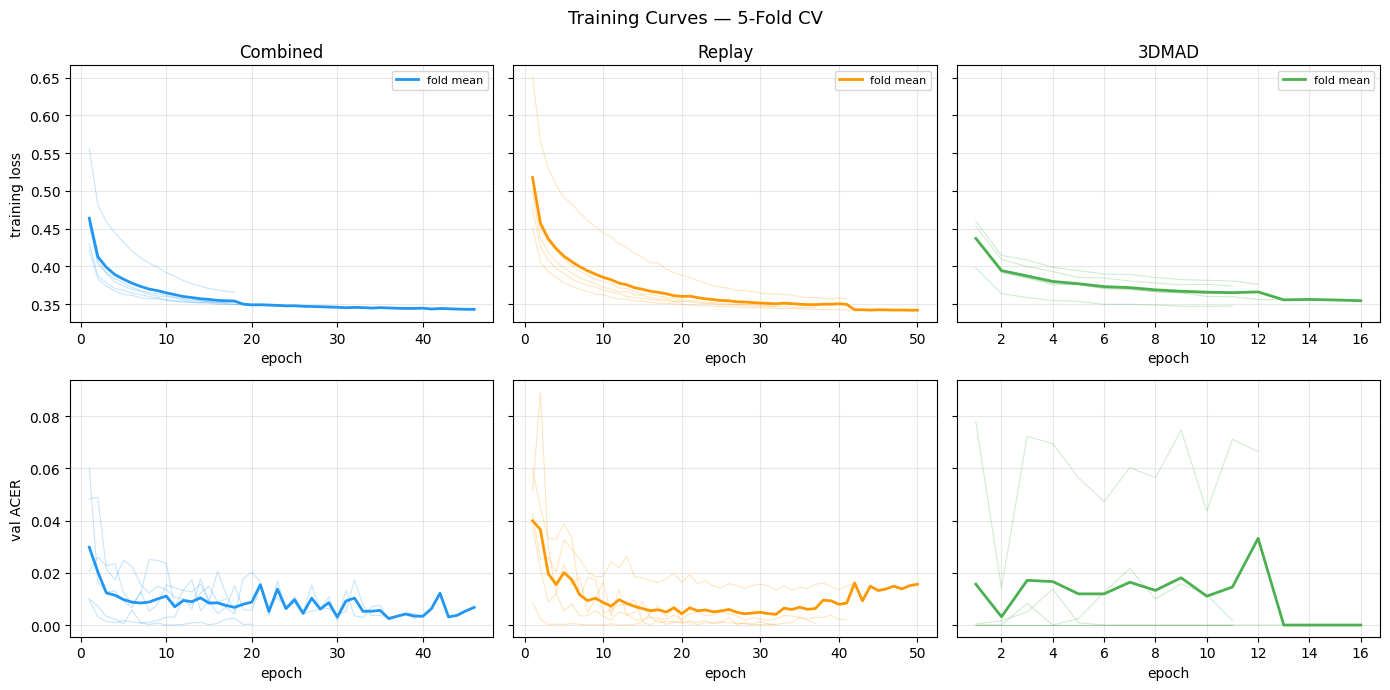

In [4]:
fig = results_viz.plot_training_curves(cv_runs)
fig.savefig(FIG_DIR / "training_curves.png")
plt.show()


### Takeaway — Training curves

- **3DMAD converges fastest** (~12 epochs on average) because it has fewer subjects
  and a single attack type. Replay and Combined take 28–36 epochs, reflecting more
  complex decision boundaries.
- **Loss and ACER decouple after the first few epochs.** Loss keeps decreasing slowly
  while ACER stabilises near zero — further loss reduction is the model becoming
  more confident, not more accurate. This is expected with label smoothing creating
  a loss floor.
- **Fold variance is low.** The thin per-fold lines track closely, confirming that
  performance is stable across subject splits.


## 2. CV fold stability

Per-fold ACER values across protocols. Dots are individual folds,
diamonds are the fold mean, boxes show the spread. Tight boxes = stable
model, wide boxes = sensitive to which subjects are held out.


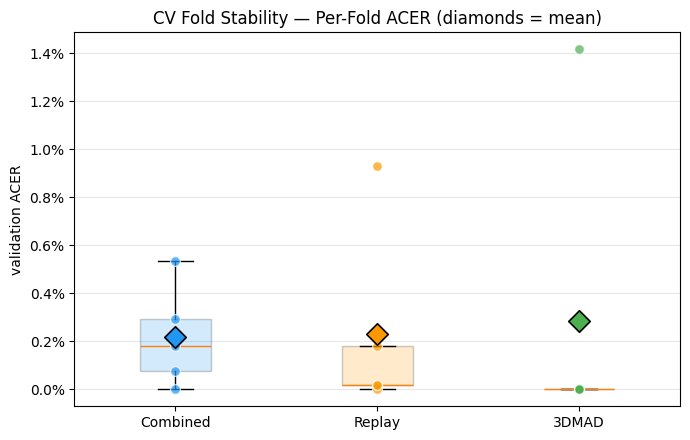

In [3]:
fig = results_viz.plot_cv_fold_spread(cv_runs)
fig.savefig(FIG_DIR / "cv_fold_spread.png")
plt.show()


### Takeaway — CV stability

- **All three protocols are stable** — ACER stays below 0.6% across every fold.
  Combined has the tightest spread (std 0.19%), confirming that more diverse
  training data produces more consistent results.
- **3DMAD has one outlier fold** with ~1.4% ACER while the other four are 0%.
  With only 17 subjects split into 5 folds (~3 per fold), a single hard
  subject has outsized impact.


## 3. Within-dataset test evaluation

ACER, APCER, and BPCER on the held-out test set for each protocol.
These are the "how well does it work on its own data" numbers.


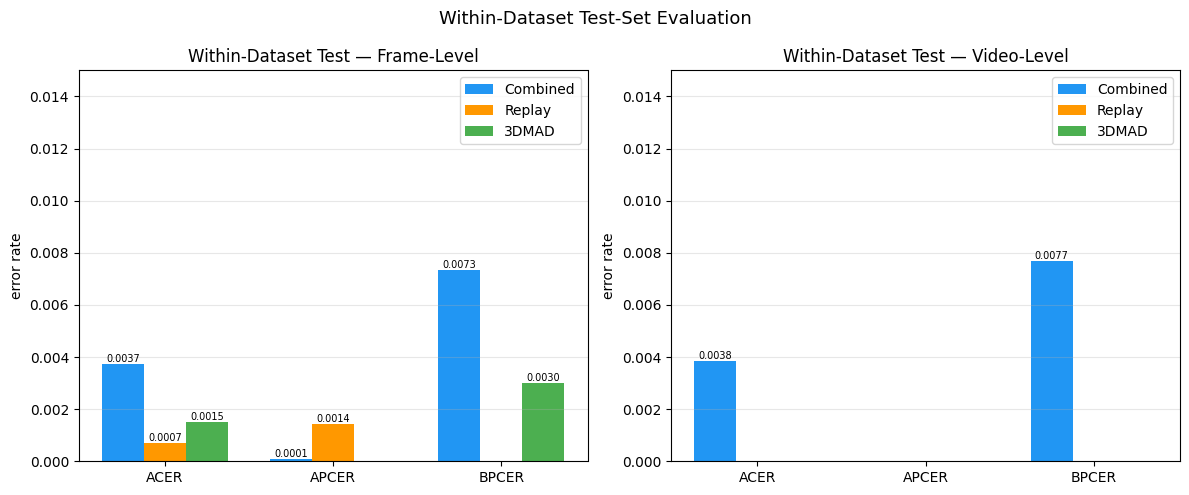

In [6]:
fig = results_viz.plot_within_dataset_bars(test_results)
fig.savefig(FIG_DIR / "within_dataset_bars.png")
plt.show()


### Takeaway — Within-dataset test

- **Near-perfect across the board.** All error rates are below 0.8%.
  At the video level, Replay and 3DMAD achieve 0% ACER — every video
  is correctly classified.
- **Combined has the highest BPCER** (0.73% frame, 0.77% video) — a
  small price for covering two domains. A few bonafide frames from one
  domain get caught by the other domain's decision boundary.


## 4. Cross-dataset generalisation

The headline experiment: train on one dataset, test on the other.
Left panel uses a fixed threshold (0.5), right panel uses the
devel-calibrated HTER (the honest protocol).


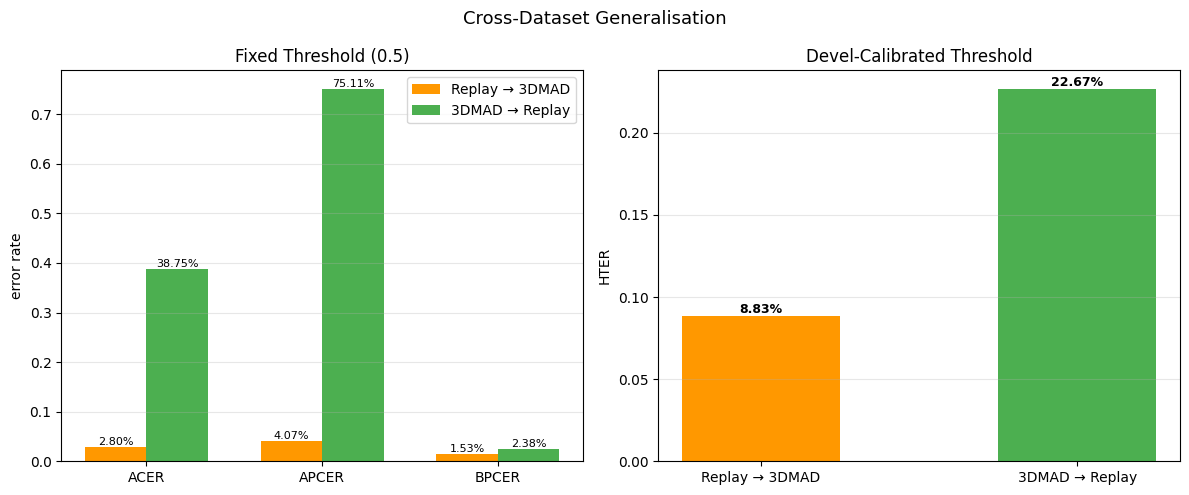

In [8]:
fig = results_viz.plot_cross_dataset_bars(test_results)
fig.savefig(FIG_DIR / "cross_dataset_bars.png")
plt.show()


### Takeaway — Cross-dataset generalisation

- **The asymmetry is stark.** Replay → 3DMAD works well (2.8% ACER),
  but 3DMAD → Replay fails badly (38.75% ACER, 75% of attacks slip through).
- **Devel calibration helps but doesn't fix it.** Adjusting the threshold
  reduces 3DMAD → Replay from 38.75% to 22.67% HTER, but it's still
  unacceptable — the model fundamentally hasn't learned to detect 2D
  replay attacks.
- **This is the strongest argument for combined training.** A model
  trained on only one attack modality cannot be trusted on another.


## 5. ROC curves

ROC curves require running inference on the test set to get per-sample
scores. The within-dataset curves will cluster near (0,1); the
cross-dataset curves will show the generalisation gap.


ROC test:   0%|          | 0/458 [00:00<?, ?it/s]

ROC test:   0%|          | 1/458 [00:00<05:45,  1.32it/s]

ROC test:   0%|          | 2/458 [00:00<02:50,  2.67it/s]

ROC test:   1%|          | 3/458 [00:00<01:54,  3.98it/s]

ROC test:   1%|          | 5/458 [00:01<01:13,  6.14it/s]

...

ROC test:  89%|████████▊ | 63/71 [00:06<00:00, 10.51it/s]

ROC test:  92%|█████████▏| 65/71 [00:06<00:00, 10.32it/s]

ROC test:  94%|█████████▍| 67/71 [00:06<00:00, 10.36it/s]

ROC test:  97%|█████████▋| 69/71 [00:06<00:00, 10.41it/s]

ROC test: 100%|██████████| 71/71 [00:07<00:00, 11.61it/s]

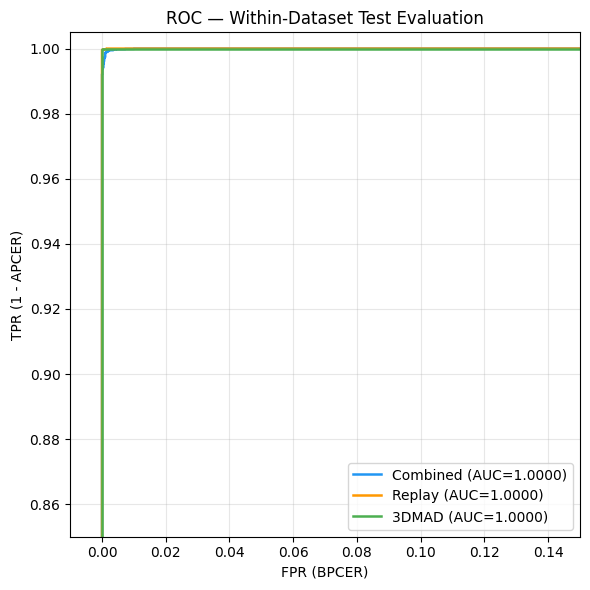

In [6]:
fig = results_viz.plot_roc_within(CHECKPOINT_DIR)
fig.savefig(FIG_DIR / "roc_within_dataset.png")
plt.show()


### Takeaway — Within-dataset ROC

- **All three curves hug the top-left corner** with AUC ≈ 1.0. The
  zoomed axes ([0, 0.15] × [0.85, 1.0]) are needed to see any
  separation at all — at full scale the curves are indistinguishable
  from perfect.


ROC test:   0%|          | 0/71 [00:00<?, ?it/s]

ROC test:   1%|▏         | 1/71 [00:00<00:31,  2.23it/s]

ROC test:   4%|▍         | 3/71 [00:00<00:12,  5.30it/s]

ROC test:   6%|▌         | 4/71 [00:00<00:10,  6.32it/s]

ROC test:   8%|▊         | 6/71 [00:00<00:08,  7.87it/s]

...

ROC test:  98%|█████████▊| 379/388 [00:36<00:00, 10.23it/s]

ROC test:  98%|█████████▊| 381/388 [00:37<00:00, 10.33it/s]

ROC test:  99%|█████████▊| 383/388 [00:37<00:00, 10.39it/s]

ROC test:  99%|█████████▉| 385/388 [00:37<00:00, 10.46it/s]

ROC test: 100%|█████████▉| 387/388 [00:37<00:00, 10.42it/s]

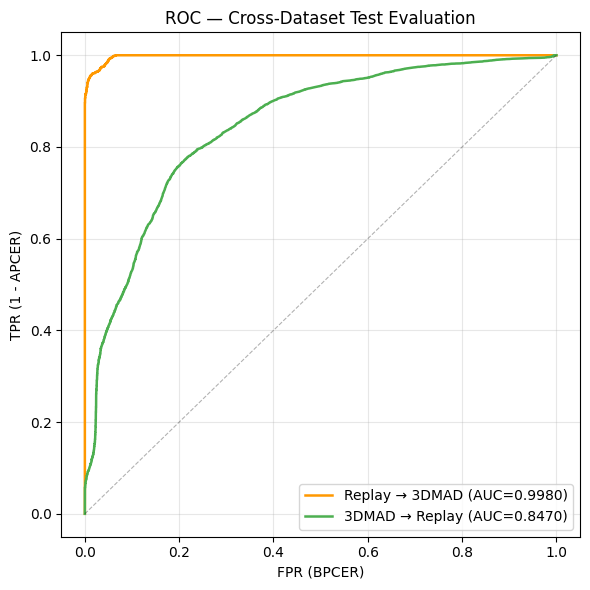

In [7]:
fig = results_viz.plot_roc_cross(CHECKPOINT_DIR)
fig.savefig(FIG_DIR / "roc_cross_dataset.png")
plt.show()


### Takeaway — Cross-dataset ROC

- **Replay → 3DMAD** (orange) maintains high AUC (~0.998), confirming
  that the Replay-trained model's scores still *rank* attacks correctly
  even on an unseen domain — the signal is there, it just needs
  threshold recalibration.
- **3DMAD → Replay** (green) drops to AUC ~0.85. The model's scores
  are not just mis-calibrated — it genuinely struggles to rank Replay
  attacks above bonafide. The 3DMAD-only model has learned features
  that don't transfer.


## 6. Summary

Key numbers for the paper:

| Experiment | Metric | Value |
|------------|--------|-------|
| Combined CV (5-fold) | ACER mean ± std | 0.22% ± 0.19% |
| Combined test | Frame ACER | 0.37% |
| Replay test | Frame ACER | 0.07% |
| 3DMAD test | Frame ACER | 0.15% |
| Replay → 3DMAD | Frame ACER | 2.80% |
| 3DMAD → Replay | Frame ACER | 38.75% |
| Replay → 3DMAD | Calibrated HTER | 8.83% |
| 3DMAD → Replay | Calibrated HTER | 22.67% |

The within-dataset results confirm that AttackNet v2.2 solves both
benchmarks individually. The cross-dataset asymmetry reveals that the
model learns dataset-specific shortcuts rather than generalizable liveness
cues — motivating combined training as the minimum viable strategy.
